# FinOps AWS Forecasting
## Using Timeseries
### Author: Jorge Rodriguez
### Date: Feb-2025
### Last Time Modified: April 2 2025
### Kernel 3.13.7

In [10]:
import boto3
from datetime import date
from dateutil.relativedelta import relativedelta
import seaborn as sns
import pandas as pd
import subprocess
from time import time, sleep
import webbrowser
from boto3.session import Session
import matplotlib.pyplot as plt
import glob
from datetime import datetime


import numpy as np
import seasonal
%matplotlib inline

from matplotlib import ticker

import xgboost as xgb
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import xgboost as xgb # brew install libomp
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

from statsmodels.tsa.filters.hp_filter import hpfilter

from prophet import Prophet
from prophet.plot import plot, plot_components



/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_13455/2689199351.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_df['Month No'] = combined_df['Month'].replace(month_name,month_number)


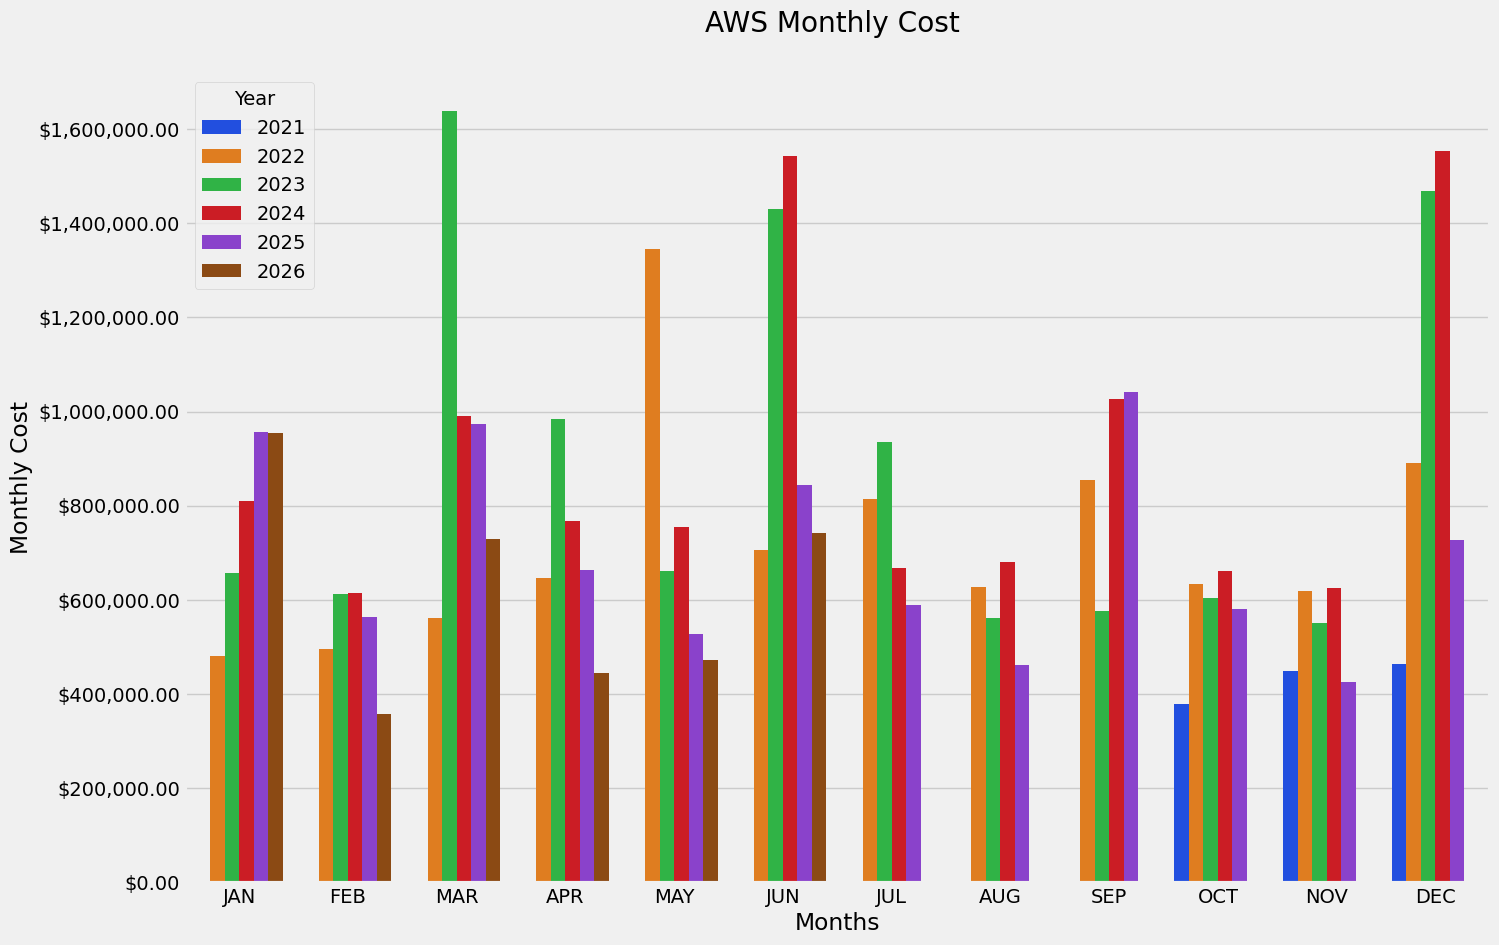

In [11]:
# Get a list of all CSV files in the directory
csv_files = glob.glob('Monthly_Cost_For_*.csv')

# Create an empty list to store the DataFrames
dfs = [] 

# Loop over each CSV file and read it into a DataFrame
for file in csv_files:
    #print("reading File: " + file)
    df = pd.read_csv(file) 
    dfs.append(df) 

# Concatenate all the DataFrames into one
combined_df = pd.concat(dfs, axis=0, ignore_index=True) 
month_name = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
month_number = [1,2,3,4,5,6,7,8,9,10,11,12]
kafka_new ='Apache Kafka® & Apache Flink® on Confluent Cloud™ - Annual Commits'
kafka_old ='Apache Kafka® on Confluent Cloud™ - Annual Commits'
combined_df['Month No'] = combined_df['Month'].replace(month_name,month_number)
combined_df['Service'] = combined_df['Service'].replace('Datadog Pro','Datadog')
combined_df['Service'] = combined_df['Service'].replace(kafka_old,kafka_new)
combined_df.to_csv("combined.csv")

#otal_per_month_df = combined_df.groupby(['Year','Month','Month No']).agg({'Cost':'sum'}).sort_values(by='Month')
total_per_month_df = combined_df.groupby(['Year','Month','Month No']).agg(Total_cost_per_Month=('Cost','sum')).sort_values(by='Month No')
total_per_month_df['Cost_in_Millions'] = total_per_month_df['Total_cost_per_Month']/1000


# Initialize the matplotlib figure
#sns.color_palette("viridis", as_cmap=True)
sns.color_palette("bright")
fig, ax = plt.subplots(figsize=(15, 10))

sns.barplot(x="Month", y="Total_cost_per_Month", data=total_per_month_df,
            hue='Year', legend=True, color='green',palette='bright')


# Add a legend and informative axis label
#ax.legend(ncol=2, loc="lower right", frameon=True)
ax.set_xlabel("Months")
ax.set_ylabel("Monthly Cost")
ax.set_title("AWS Monthly Cost \n")
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,.2f}".format(int(x))))
plt.show()




# Time Series Exploration 

In [12]:
split_date = '07-01-2025'### (M-D-Y) 12 months before the last day of a full month we are on the calendar year. <March> 
last_date = '03-01-2026' ### <April> and will keep moving as we move on the calendar

# Moving to 3 months 

In [13]:
split_date = '07-01-2025'### (M-D-Y) 3 months before the last day of a full month we are on the calendar year. <March> 
last_date = '03-01-2026' ### <Jun> and will keep moving as we move on the calendar

In [14]:
def create_features(df):
    '''
    Create time series features based on time series index
    '''
    df = df.copy()
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.day_of_week
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['quarter'] = df.index.quarter
    df['1_month_lag'] = df['Cost'].shift(1)
    df['2_month_lag'] = df['Cost'].shift(2)
    df['3_month_lag'] = df['Cost'].shift(3)
    df['6_month_lag'] = df['Cost'].shift(6)
    #df['12_month_lag'] = df['Cost'].shift(12)
    #df['24_month_lag'] = df['Cost'].shift(24)
    df['3_month_mean'] = df['Cost'].rolling(window = 3).mean()
    df['3_month_mean'] = df['Cost'].rolling(window = 3).std()
    df['3_month_max'] = df['Cost'].rolling(window = 3).max()
    df['3_month_min'] = df['Cost'].rolling(window = 3).min()
    df['6_month_mean'] = df['Cost'].rolling(window = 6).mean()
    df['6_month_std'] = df['Cost'].rolling(window = 6).std()
    df['6_month_max'] = df['Cost'].rolling(window = 6).max()
    df['6_month_min'] = df['Cost'].rolling(window = 6).min()
    #df['12_month_mean'] = df['Cost'].rolling(window = 12).mean()
    #df['24_month_mean'] = df['Cost'].rolling(window = 24).mean()
    #df['12_month_std'] = df['Cost'].rolling(window = 12).std()
    #df['24_month_std'] = df['Cost'].rolling(window = 24).std()
    #df['12_month_max'] = df['Cost'].rolling(window = 12).max()
    #df['24_month_max'] = df['Cost'].rolling(window = 24).max()
    #df['12_month_min'] = df['Cost'].rolling(window = 12).min()
    #df['24_month_min'] = df['Cost'].rolling(window = 24).min()
    return df

In [ ]:
#combined_df.info()

In [15]:
df_ml = combined_df.copy()

# 1. Create a temporary DataFrame with the required column names
# We force 'Month No' to numeric, converting errors to NaN (which become NaT in dates)
date_cols = pd.DataFrame({
    'year': df_ml['Year'],
    'month': pd.to_numeric(df_ml['Month No'], errors='coerce'),
    'day': 1  # Standardizes all days to the 1st of the month
})

# Zip the columns together and construct native Python datetimes
df_ml['Date'] = [
    datetime(int(y), int(m), int(d)) 
    for y, m, d in zip(date_cols['year'], date_cols['month'], date_cols['day'])
]

In [ ]:
#date_cols.info()

In [11]:
#date_cols.head(10)

/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_13455/788412948.py:6: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df_ml = df_ml.groupby(by=['Date']).agg({'Cost':sum})
/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_13455/788412948.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['${:,}'.format(int(val)) for val in current_values])
/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_13455/788412948.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['${:,}'.format(int(val)) for val in current_values])


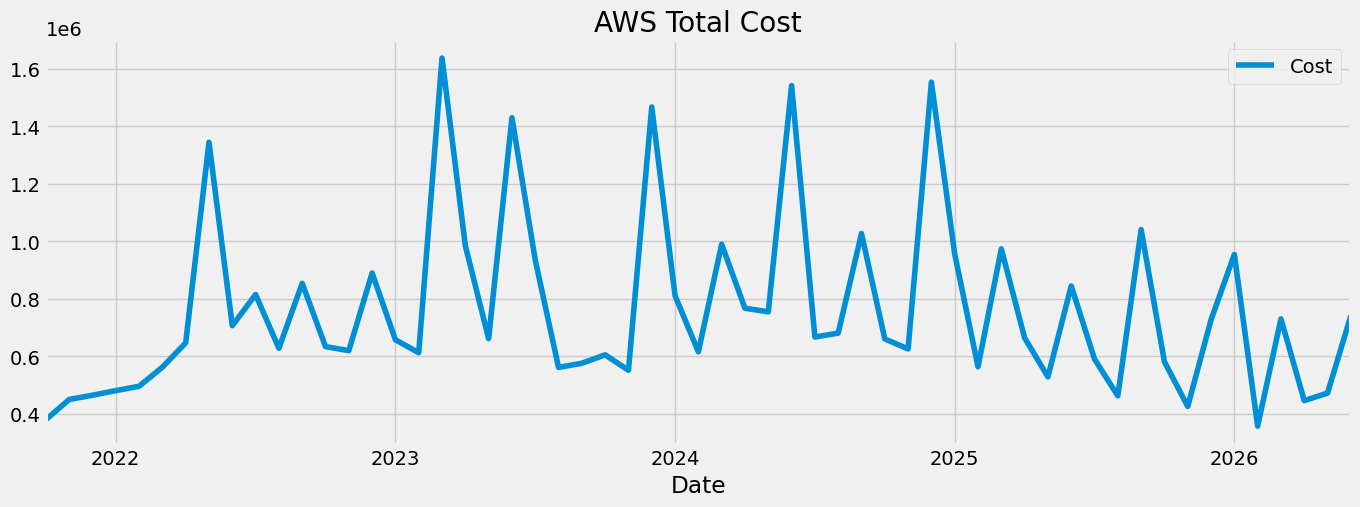

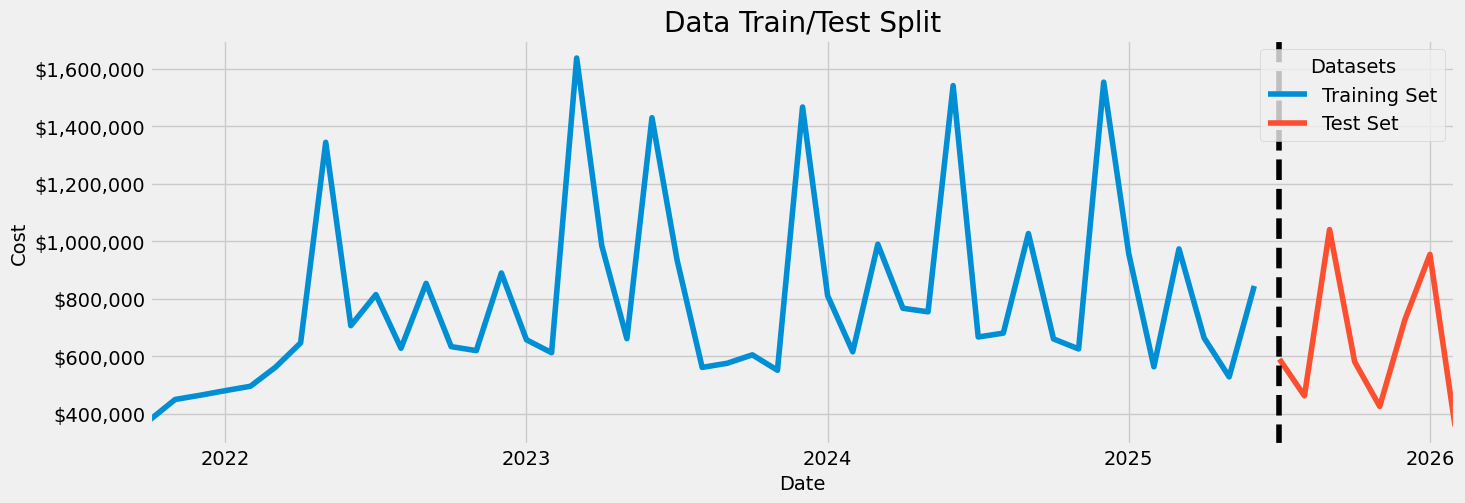

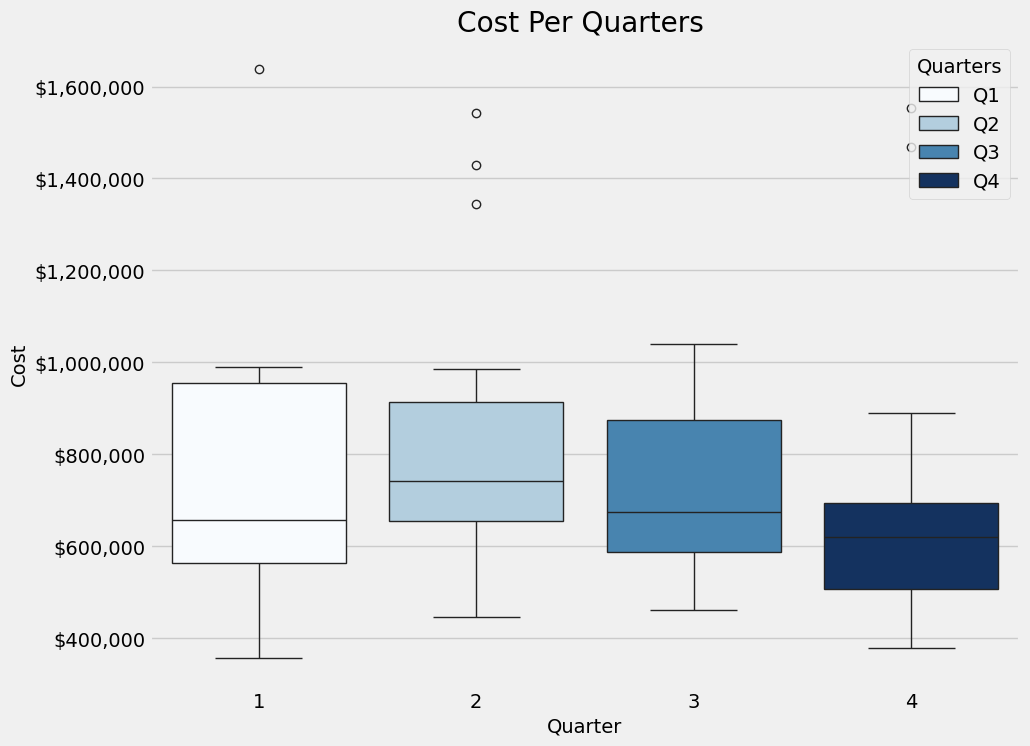

[0]	validation_0-rmse:314764.30873	validation_1-rmse:278404.57180
[100]	validation_0-rmse:196734.43050	validation_1-rmse:224381.86460
[200]	validation_0-rmse:134462.59626	validation_1-rmse:211975.76866
[300]	validation_0-rmse:96010.86797	validation_1-rmse:204201.01892
[400]	validation_0-rmse:72223.57130	validation_1-rmse:199994.34026
[479]	validation_0-rmse:59781.92045	validation_1-rmse:198846.39632


/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_13455/788412948.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['${:,}'.format(int(val)) for val in current_values])


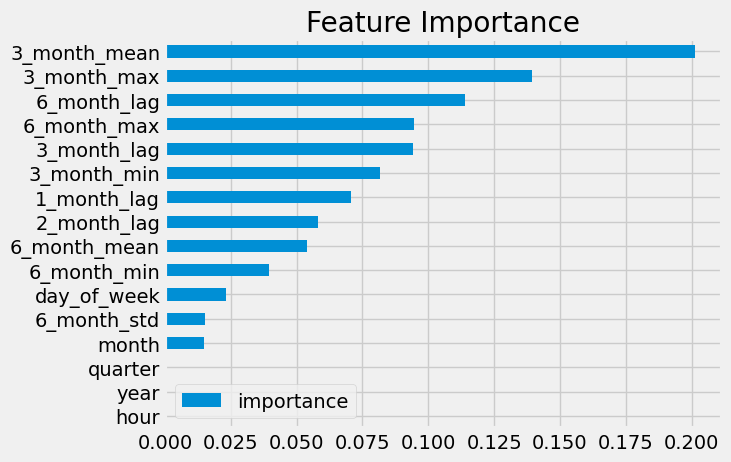

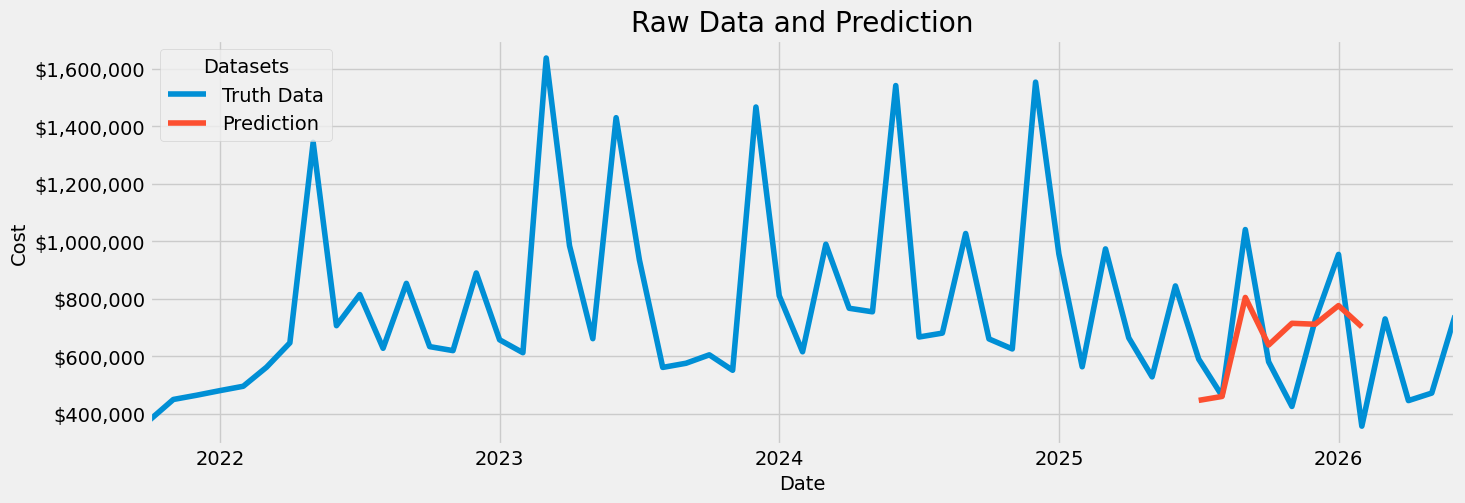

RMSE Score on Test Set: 198,401.97
RMSE Score on Test Set: 198,401.97


/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_13455/788412948.py:112: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df_now = df_now.groupby(by=['Date']).agg({'Cost':sum})
/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_13455/788412948.py:148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['${:,}'.format(int(val)) for val in current_values])


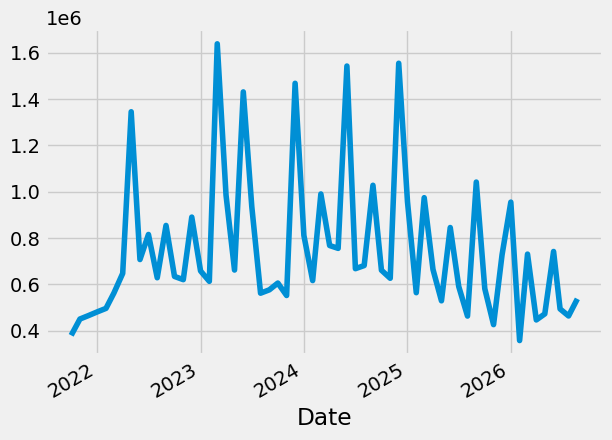

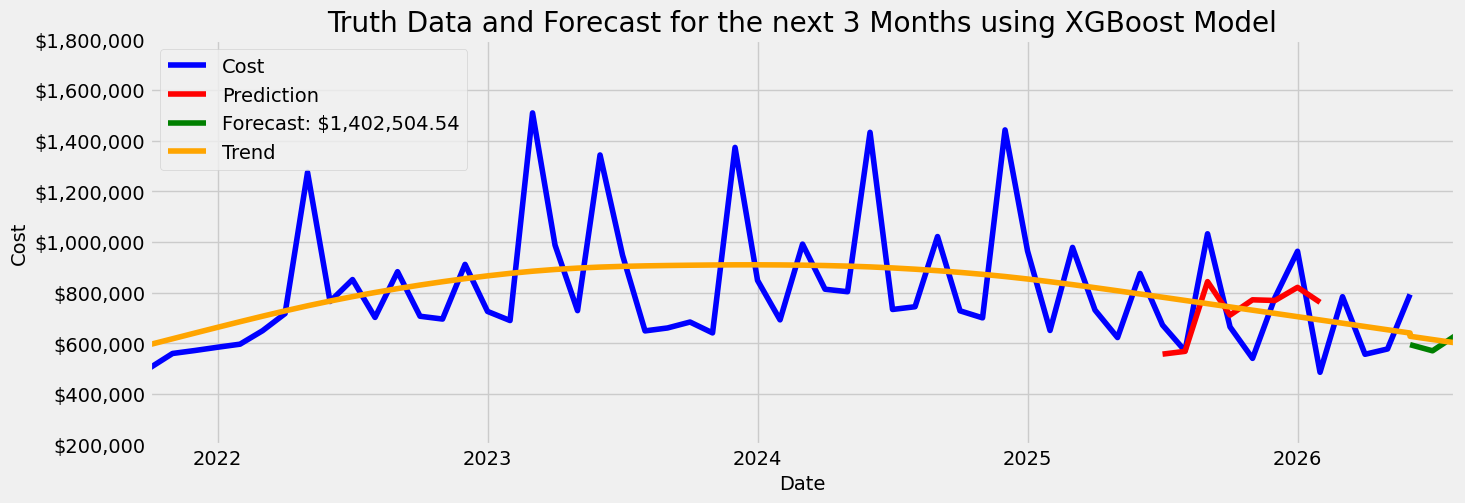

In [16]:
#df_ml =combined_df.copy()
#df_ml['Date_str'] = df_ml['Year'].apply(lambda x: str(x)) + "-" + df_ml['Month No'].apply(lambda x: str(x)) + "-01"
#df_ml['Date'] = pd.to_datetime(df_ml['Date_str'])
df_ml.set_index('Date')
#df_ml.index = pd.to_datetime(df_ml.index)
df_ml = df_ml.groupby(by=['Date']).agg({'Cost':sum})


df_ml.plot(style='-', figsize=(15,5), color=color_pal[0], title='AWS Total Cost')

#---------------------------------------------------------------------------------
train = df_ml.loc[df_ml.index < split_date]
test = df_ml.loc[(df_ml.index >= split_date) & (df_ml.index < last_date)]

fig, ax = plt.subplots(figsize=(15,5))
formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label = 'Test Set')
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['${:,}'.format(int(val)) for val in current_values])
ax.axvline(split_date, color='black', ls='--')
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Cost", fontsize=14)
ax.legend(['Training Set', 'Test Set'], loc='upper right', title='Datasets')


#---------------------------------------------------------------------------------
df_ml = create_features(df_ml)
fix, ax = plt.subplots(figsize=(10,8))
formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)
sns.boxplot(data=df_ml, x='quarter', y='Cost', palette='Blues', hue='quarter')
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['${:,}'.format(int(val)) for val in current_values])
ax.set_title('Cost Per Quarters ')
ax.legend(['Q1', 'Q2', 'Q3', 'Q4'], loc='upper right', title='Quarters')
ax.set_xlabel("Quarter", fontsize=14)
ax.set_ylabel("Cost", fontsize=14)
plt.show()

#---------------------------------------------------------------------------------
train = create_features(train)
test = create_features(test)

FEATURES = train.columns[1:]
TARGET = train.columns[0]

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

# regresion model
reg = XGBRegressor(n_estimators = 12000,
                   early_stopping_rounds = 40,
                   learning_rate=0.01,
                   max_depth=2,
                   random_state=42
                   )

#reg = xgb.XGBRegressor()

reg.fit(X_train, y_train,
        eval_set = [(X_train,y_train), (X_test, y_test)],
        verbose = 100)

fi = pd.DataFrame(data=reg.feature_importances_, index=reg.feature_names_in_,columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title="Feature Importance")

#---------------------------------------------------------------------------------
test['predictions'] = reg.predict(X_test)
df_ml1 = df_ml.merge(test[['predictions']], how='left', left_index=True, right_index=True)

ax = df_ml1[['Cost']].plot(figsize=(15,5))
formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['${:,}'.format(int(val)) for val in current_values])
df_ml1['predictions'].plot(ax=ax, style='-')
ax.set_title('Raw Data and Prediction')
ax.legend(['Truth Data', 'Prediction'], loc='upper left', title='Datasets')
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Cost", fontsize=14)
plt.show()

score = np.sqrt(mean_squared_error(test['Cost'], test['predictions']))
print(f'RMSE Score on Test Set: {score:,.2f}')
num = "{:,.2f}".format(score)
print('RMSE Score on Test Set:', num)


#---------------------------------------------------------------------------------
from xgboost import XGBRegressor
model = XGBRegressor()

PERIODS = 3 # Number of months to forecast

#Cost = df_ml[-12:]['Cost'].values # for 12 months
Cost = df_ml[-PERIODS:]['Cost'].values # for 3 months
#Date_str = df_ml[-12:].index.values + pd.to_timedelta(52, 'W') # for 12 months 
Date_str = df_ml[-PERIODS:].index.values + pd.to_timedelta((PERIODS*4), 'W') # for 3 months 
data = {'Date_str': Date_str,'Cost' : Cost}
df_now = pd.DataFrame(data)
df_now['Date'] = pd.to_datetime(df_now['Date_str'])
df_now.set_index('Date')
df_now.index = pd.to_datetime(df_now.index)
df_now = df_now.groupby(by=['Date']).agg({'Cost':sum})
df_now = create_features(df_now)
df_now.drop('Cost', axis=1, inplace=True)
df_now['predictions'] = reg.predict(df_now)

df_new = pd.DataFrame()
df1_date =  df_ml.index.values
df1_date = np.append(df1_date, df_now.index.values)
df1_cost = df_ml['Cost'].values
df1_cost = np.append(df1_cost, df_now['predictions'].values)

df_new['Date'] = df1_date
df_new['Cost'] = df1_cost

df_new.set_index('Date')
df_new.index = pd.to_datetime(df_new.index)
df_new_1 = df_new.groupby(['Date']).agg(Cost=('Cost','sum'))
df_new_1['Cost'].plot()

#----------------------------------------------------------------------------------
cost_cycle, cost_trend = hpfilter(df_new_1['Cost'], lamb=1600) # 1600 for Quarterly data, 6.25  for yerly data and 129600 for monthly data
df_new_1['Trend'] = cost_trend

yhat = df_now['predictions'].values
#"{:,.2f}".format(yhat[0:-1].sum()+df_ml['Cost'].values[-13])

fig1, ax = plt.subplots(figsize=(15,5))
df_ml[['Cost']].plot(ax=ax, style='-', label= 'Truth Data', color='blue')
df_ml1['predictions'].plot(ax=ax, style='-', label= 'Prediction', color='red')
df_now['predictions'].plot(ax=ax, style='-', label= 'Forecast: '+str("${:,.2f}".format(yhat[0:-1].sum()+df_ml['Cost'].values[-PERIODS])), color='green')
#df1[['Trend']].plot(ax=ax).autoscale(axis='x', tight=True)
df_new_1[['Trend']].plot(ax=ax, label='Trend', color='orange')
formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['${:,}'.format(int(val)) for val in current_values])
# ax.set_title('Truth Data, Prediction and Forecast for 2025 (XGBoost)')
ax.set_title(f'Truth Data and Forecast for the next {PERIODS} Months using XGBoost Model')
ax.legend(loc='upper left', title='')
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Cost", fontsize=14)
ax.set_ylim(bottom=000000,top=2000000)
plt.show()





# Using Prophet

12:26:58 - cmdstanpy - INFO - Chain [1] start processing
Python(17546) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
12:26:58 - cmdstanpy - INFO - Chain [1] done processing
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
/var/folders/bc/rbbb9nc96zd3bj2l2mq3klq00000gp/T/ipykernel_13455/2610954466.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['${:,}'.format(int(val)) for val in current_values])


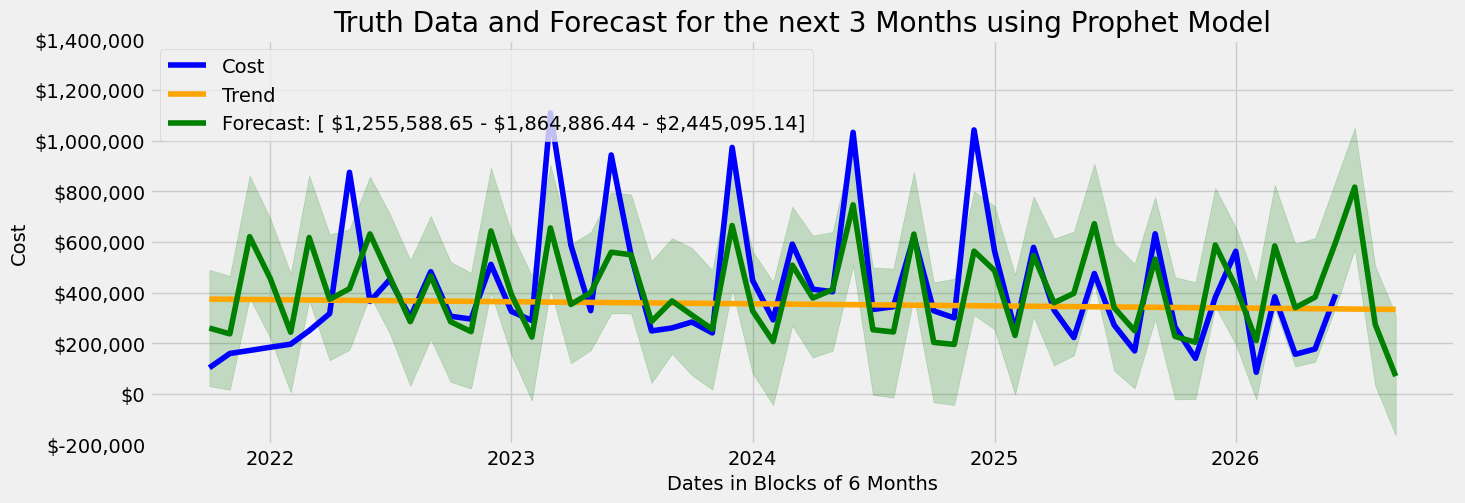

In [17]:
df_ml_p =combined_df.copy()
df_ml_p = pd.read_csv("combined.csv")
df_ml_p['Date_str'] = df_ml_p['Year'].apply(lambda x: str(x)) + "-" + df_ml_p['Month No'].apply(lambda x: str(x)) + "-01"
df_ml_p['ds'] = pd.to_datetime(df_ml_p['Date_str'])
df_ml_p['y'] = df_ml_p['Cost']
df_ml_p = df_ml_p.groupby(['ds']).agg(y=('Cost','sum'))

df_p = pd.DataFrame()

df_p['ds'] = df_ml_p.index
df_p['y'] = df_ml_p['y'].values
df_p = df_p.reset_index(drop=True)

model = Prophet()
model.fit(df_p)

PERIODS = 3  # Number of periods to forecast
# Python
future = model.make_future_dataframe(periods=PERIODS, freq='M', include_history = True)   # Create a future DataFrame for PERIODS months
forecast = model.predict(future)                             # Generate the forecast

periods = PERIODS  # Number of periods to forecast
yhat_low = forecast.iloc[-periods:,:]['yhat_lower'].values
yhat = forecast.iloc[-periods:,:]['yhat'].values
yhat_high = forecast.iloc[-periods:,:]['yhat_upper'].values


yhat = forecast.iloc[-periods:,:]['yhat'].values
fig, ax = plt.subplots(figsize=(15,5))
plt.plot(df_p['ds'], df_p['y'], label='Cost',color='blue')
plt.plot(forecast['ds'], forecast['trend'], label='Trend',color='orange')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast: [ ' + str("${:,.2f}".format(yhat_low[0:-1].sum())) + " - " + str("${:,.2f}".format(yhat[0:-1].sum())) + 
                                                                      " - " + str("${:,.2f}".format(yhat_high[0:-1].sum()))+ ']',color='green')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='green', alpha=0.2)
#plt.plot(forecast['ds'], forecast['yhat_lower'], label='Forecast',color='green', linestyle='--')
#plt.plot(forecast['ds'], forecast['yhat_upper'], label='Forecast',color='green', linestyle='--')
#model.plot(forecast, ax=ax)       # Plot the forecast
#plot(model, forecast)               # Plot the forecast
#plot_components(model, forecast)    # Plot the forecast components
formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['${:,}'.format(int(val)) for val in current_values])
ax.set_title(f'Truth Data and Forecast for the next {PERIODS} Months using Prophet Model')
#ax.legend(['Truth Data', 'Prediction','Forecast'], loc='upper left', title='Datesets')
ax.legend(loc='upper left', title='')
ax.set_xlabel("Dates in Blocks of 6 Months", fontsize=14)
ax.set_ylabel("Cost", fontsize=14)
ax.set_ylim(bottom=000000,top=2000000)
plt.show()




In [93]:
#df_p.plot(style='-', figsize=(15,5), color=color_pal[0], title='AWS Total Cost')

In [118]:
#! pip3 install plotly --upgrade

# More Analysys -- Lag Plot & Auto Regresion

In [13]:
import datetime as dt
import os
import warnings
from collections import UserDict
from glob import glob

from IPython.display import Image

pd.options.display.float_format = "{:,.2f}".format
np.set_printoptions(precision=2)
warnings.filterwarnings("ignore")

from pandas.plotting import lag_plot


In [14]:
plt.figure()


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [96]:
combined_df = pd.read_csv("combined.csv")
df_dl_p =combined_df.copy()
df_dl_p['Date_str'] = df_dl_p['Year'].apply(lambda x: str(x)) + "-" + df_dl_p['Month No'].apply(lambda x: str(x)) + "-01"
df_dl_p['Date'] = pd.to_datetime(df_dl_p['Date_str'])
df_dl_p.set_index('Date')
df_dl_p.index = pd.to_datetime(df_dl_p.index)
df_dl_p = df_dl_p.groupby(['Date']).agg(Cost=('Cost','sum'))


In [97]:
df_dl_p

,Cost
Date,
2021-10-01,3.794357e+05
2021-11-01,4.499119e+05
2021-12-01,4.646831e+05
2022-01-01,4.806844e+05
2022-02-01,4.958688e+05
2022-03-01,5.622309e+05
2022-04-01,6.468500e+05
2022-05-01,1.344622e+06
2022-06-01,7.066702e+05


<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

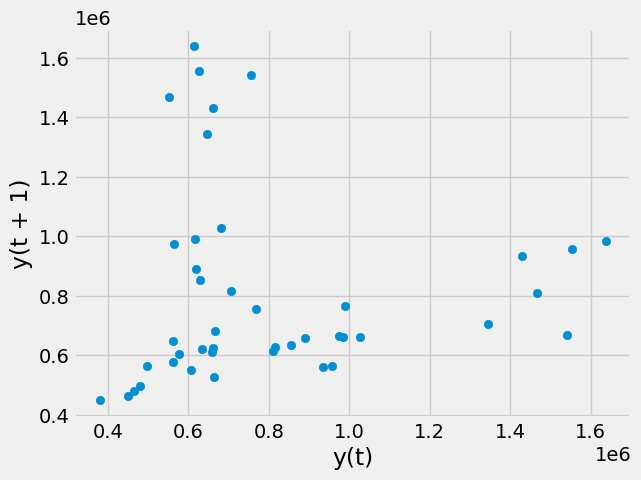

In [17]:
lag_plot(df_dl_p)

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

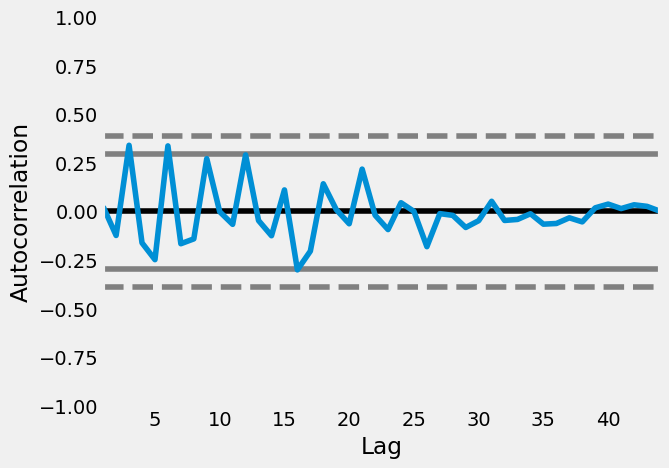

In [18]:
from pandas.plotting import autocorrelation_plot
plt.figure()
autocorrelation_plot(df_dl_p)

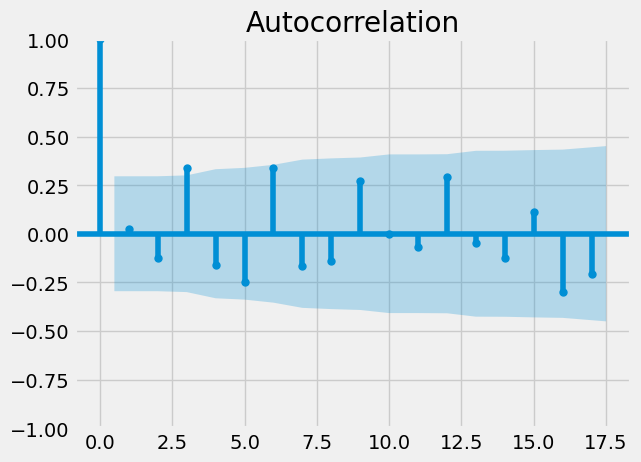

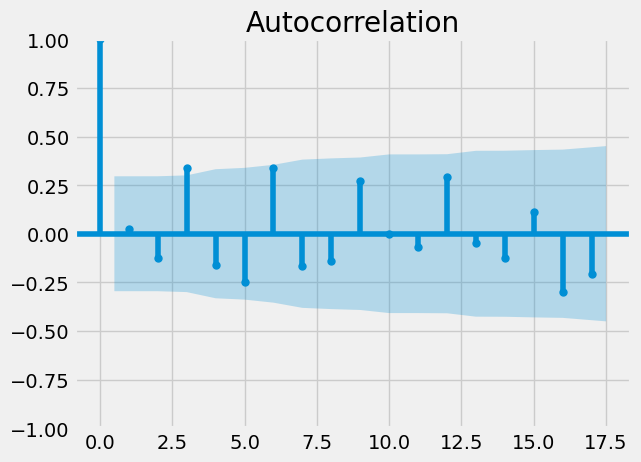

In [19]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df_dl_p)
#pyplot.show()


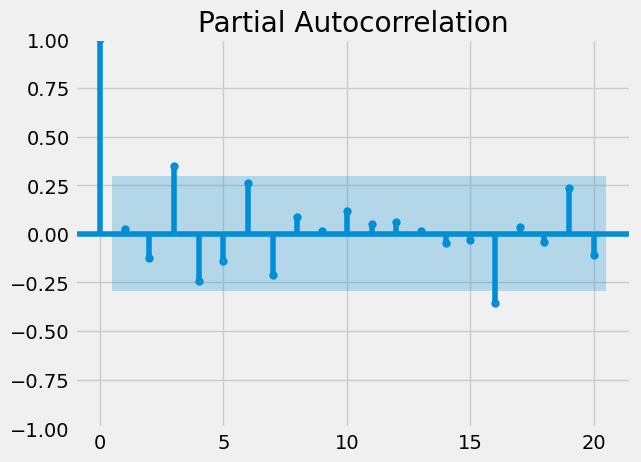

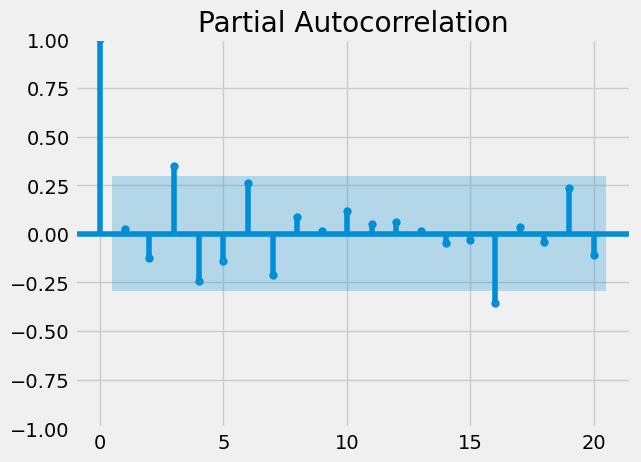

In [20]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df_dl_p, lags=20)

In [21]:
from statsmodels.tsa.ar_model import AutoReg, ar_select_order
from statsmodels.tsa.api import acf, pacf, graphics

# Apply the model 
model = AutoReg(df_dl_p, 1)
results = model.fit(cov_type="HC0")
#results = model.fit()
results.summary()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                   Cost   No. Observations:                   44
Model:                     AutoReg(1)   Log Likelihood                -605.670
Method:               Conditional MLE   S.D. of innovations         316924.747
Date:                Mon, 02 Jun 2025   AIC                           1217.341
Time:                        09:10:05   BIC                           1222.624
Sample:                    11-01-2021   HQIC                          1219.289
                         - 05-01-2025                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.874e+05   1.22e+05      6.453      0.000    5.48e+05    1.03e+06
Cost.L1        0.0231      0.106      0.217      0.828      -0.185       0.231
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1           43.3282           +0.0000j           43.3282            0.0000
-----------------------------------------------------------------------------
"""

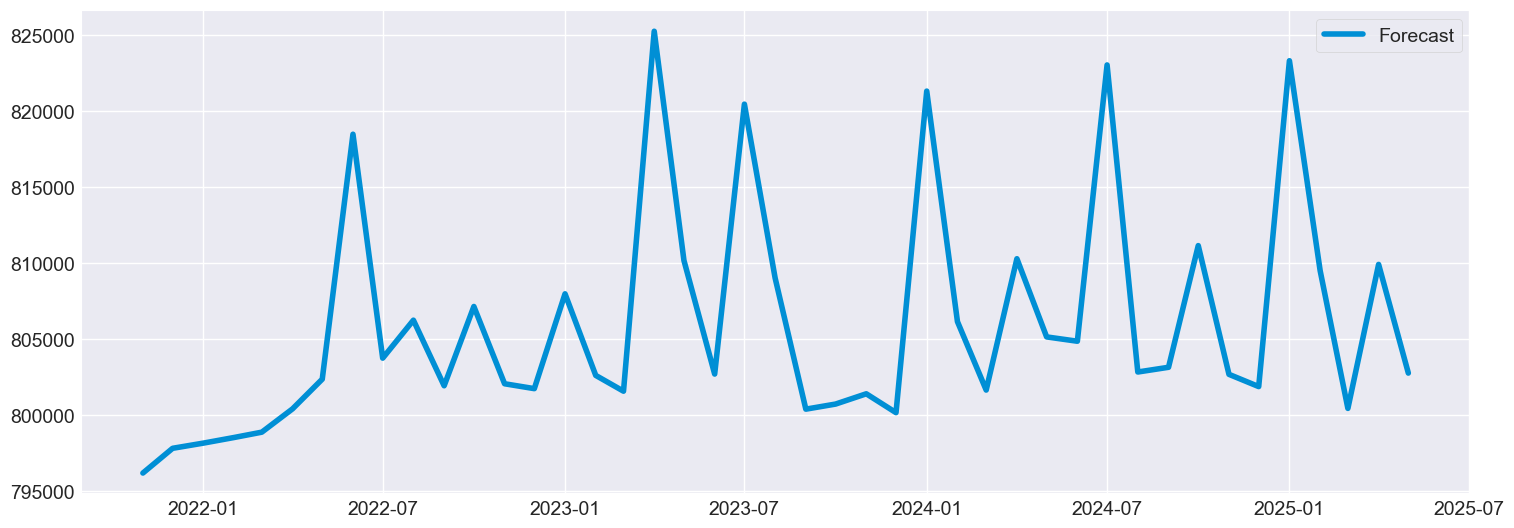

In [22]:
sns.set_style("darkgrid")
pd.plotting.register_matplotlib_converters()

sns.mpl.rc("figure", figsize=(16,6))

figure = results.plot_predict()

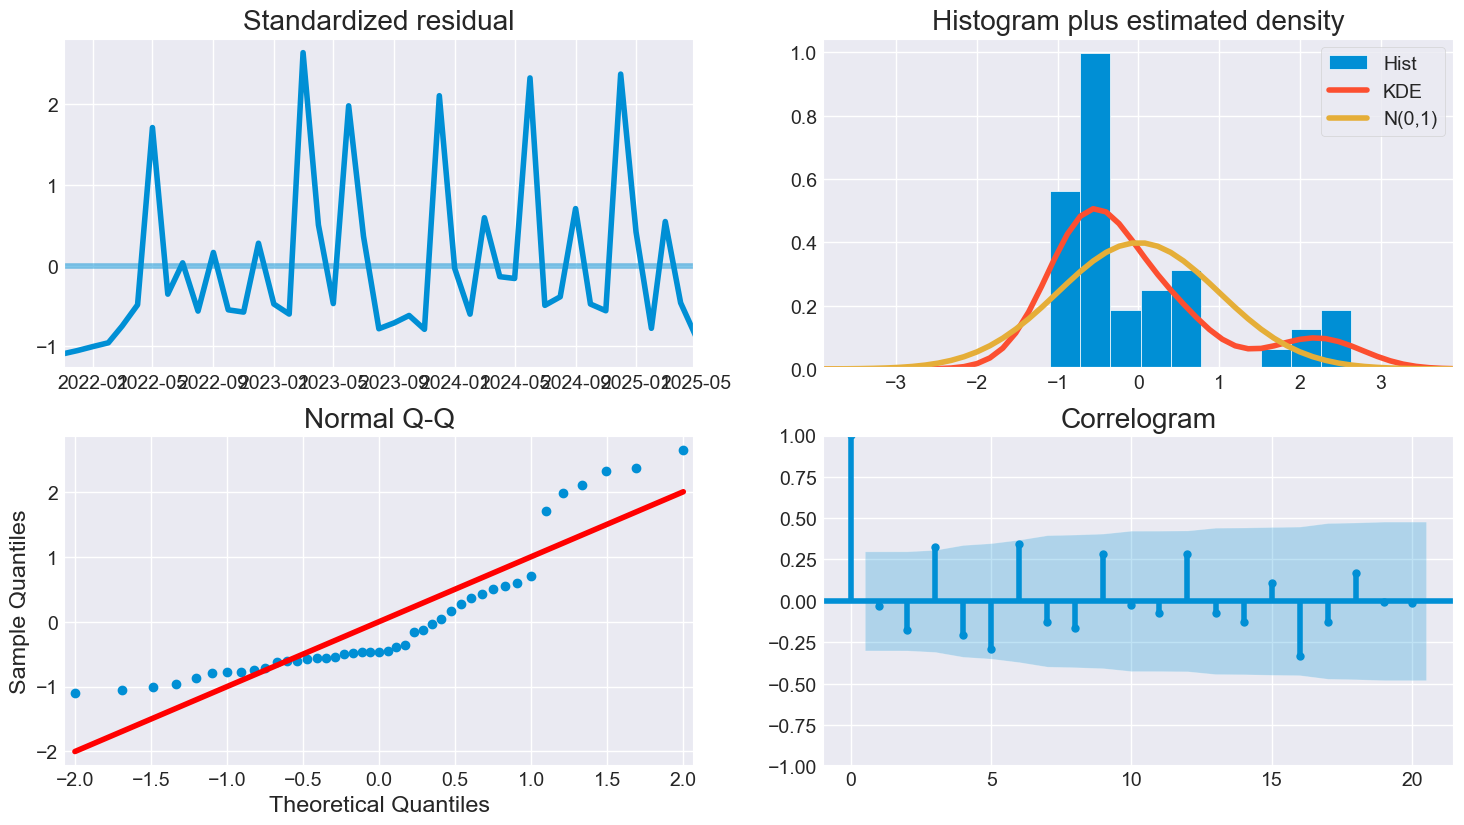

In [23]:
fig = plt.figure(figsize=(16,9))
fig = results.plot_diagnostics(fig=fig, lags=20)

In [20]:
splite_date = '02-01-2024'### (M-D-Y) 12 months before the last day of a full month we are on the calendar year. <March> 
last_date = '03-01-2025' ### <March> and will keep moving as we move on the calendar

In [21]:
train = df_dl_p.loc[df_dl_p.index < splite_date]
test = df_dl_p.loc[(df_dl_p.index >= splite_date) & (df_dl_p.index < last_date)]

In [22]:
print("Data Shape ", df_dl_p.shape)
print("Training Data Shape ", train.shape)
print("Test Data Shape", test.shape)



Data Shape  (42, 1)
Training Data Shape  (28, 1)
Test Data Shape (13, 1)


In [23]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train['Cost'] = scaler.fit_transform(train)
test['Cost'] = scaler.fit_transform(test)


In [24]:
HORIZON = 3

In [25]:
test_shifted = test.copy()
for t in range(1, HORIZON):
    test_shifted['Cost' + str(t)] = test_shifted['Cost'].shift(-t)
test_shifted = test_shifted.dropna(how='any')
test_shifted.head(10)

,Cost,Cost1,Cost2
Date,,,
2024-02-01,0.05,0.43,0.21
2024-03-01,0.43,0.21,0.19
2024-04-01,0.21,0.19,0.99
2024-05-01,0.19,0.99,0.10
2024-06-01,0.99,0.10,0.12
2024-07-01,0.10,0.12,0.47
2024-08-01,0.12,0.47,0.10
2024-09-01,0.47,0.10,0.06
2024-10-01,0.10,0.06,1.00


In [26]:
training_window = 11

train_ts = train['Cost']
test_ts = test_shifted

history = [x for x in train_ts]
history = history[ (-training_window) :]

predictions = list()

for t in range(test_ts.shape[0]):
    model = AutoReg(history, 1)
    model_fit = model.fit()
    yhat = model_fit.forecast(steps=HORIZON)
    predictions.append(yhat)
    obs = list(test_ts.iloc[t])
    history.append(obs[0])
    history.pop(0)
    print(test_ts.index[t])
    print(t + 1, ": predicted =", yhat, "expected =", obs)


2024-02-01 00:00:00
1 : predicted = [0.38 0.38 0.38] expected = [0.0527322565055639, 0.43044637045661727, 0.20558726418064754]
2024-03-01 00:00:00
2 : predicted = [0.36 0.34 0.34] expected = [0.43044637045661727, 0.20558726418064754, 0.1931791544402326]
2024-04-01 00:00:00
3 : predicted = [0.35 0.36 0.36] expected = [0.20558726418064754, 0.1931791544402326, 0.9878956821605382]
2024-05-01 00:00:00
4 : predicted = [0.3 0.3 0.3] expected = [0.1931791544402326, 0.9878956821605382, 0.10466623851628543]
2024-06-01 00:00:00
5 : predicted = [0.29 0.27 0.27] expected = [0.9878956821605382, 0.10466623851628543, 0.11826382600187435]
2024-07-01 00:00:00
6 : predicted = [0.19 0.37 0.33] expected = [0.10466623851628543, 0.11826382600187435, 0.4682103642088633]
2024-08-01 00:00:00
7 : predicted = [0.43 0.32 0.36] expected = [0.11826382600187435, 0.4682103642088633, 0.09793643511728123]
2024-09-01 00:00:00
8 : predicted = [0.41 0.32 0.35] expected = [0.4682103642088633, 0.09793643511728123, 0.06274614

# Prepare Data for Time Series

In [27]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as da
from collections import UserDict
from sklearn.preprocessing import MinMaxScaler
from IPython.display import Image
%matplotlib

pd.options.display.float_format = '{:,.2f}'.format
np.set_printoptions(precision=2)
warnings.filterwarnings("ignore")



Using matplotlib backend: inline


In [28]:
splite_date = '02-01-2024'### (M-D-Y) 12 months before the last day of a full month we are on the calendar year. <March> 
last_date = '03-01-2025' ### <March> and will keep moving as we move on the calendar

In [41]:
valid_st_data_load = "2024-01-01 00:00:00" # Y-M-D
test_st_data_load = "2025-01-01 00:00:00"

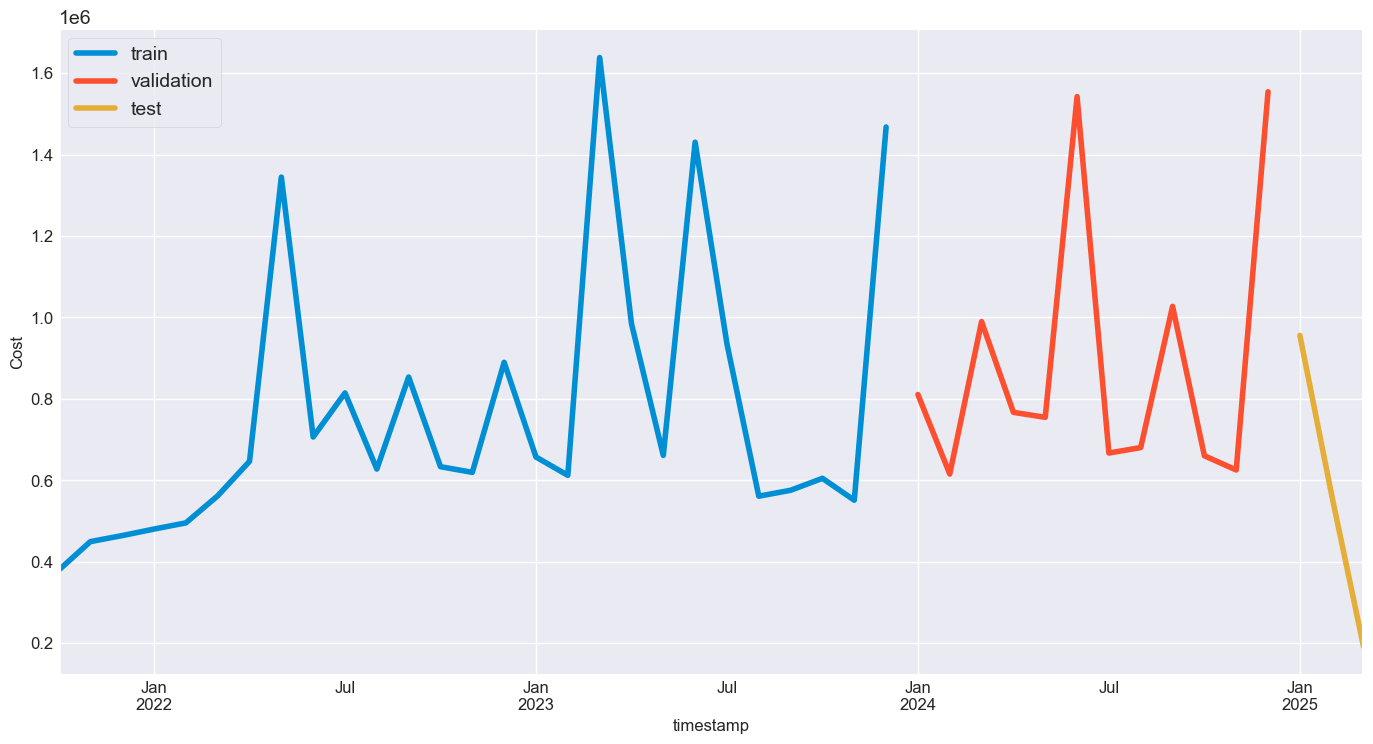

In [42]:
df_dl_p[df_dl_p.index < valid_st_data_load][["Cost"]].rename(columns={"Cost": "train"}).join(
    df_dl_p[(df_dl_p.index >= valid_st_data_load) & (df_dl_p.index < test_st_data_load)][
        ["Cost"]
    ].rename(columns={"Cost": "validation"}),
    how="outer",
).join(
    df_dl_p[test_st_data_load:][["Cost"]].rename(columns={"Cost": "test"}), how="outer"
).plot(
    y=["train", "validation", "test"], figsize=(15, 8), fontsize=12
)
plt.xlabel("timestamp", fontsize=12)
plt.ylabel("Cost", fontsize=12)
plt.show()

In [51]:
T = 6
HORIZON = 6
train = df_dl_p.copy()[df_dl_p.index < valid_st_data_load][["Cost"]]

scaler = MinMaxScaler()
train["Cost"] = scaler.fit_transform(train)

train_shifted = train.copy()
train_shifted["y_t+1"] = train_shifted["Cost"].shift(-1)
for t in range(1, T + 1):
    train_shifted[str(T - t)] = train_shifted["Cost"].shift(T - t)
y_col = "y_t+1"
X_cols = ["Cost_t-5", "Cost_t-4", "Cost_t-3", "Cost_t-2", "Cost_t-1", "Cost_t"]
train_shifted.columns = ["Cost_original"] + [y_col] + X_cols

train_shifted = train_shifted.dropna(how="any")
train_shifted.head(5)

,Cost_original,y_t+1,Cost_t-5,Cost_t-4,Cost_t-3,Cost_t-2,Cost_t-1,Cost_t
Date,,,,,,,,
2022-03-01,0.15,0.21,0.00,0.06,0.07,0.08,0.09,0.15
2022-04-01,0.21,0.77,0.06,0.07,0.08,0.09,0.15,0.21
2022-05-01,0.77,0.26,0.07,0.08,0.09,0.15,0.21,0.77
2022-06-01,0.26,0.35,0.08,0.09,0.15,0.21,0.77,0.26
2022-07-01,0.35,0.20,0.09,0.15,0.21,0.77,0.26,0.35


In [73]:
y_train = train_shifted[y_col].to_numpy()
X_train = train_shifted[X_cols].to_numpy()

In [75]:
X_train.shape

(21, 6)

In [76]:
X_train = X_train.reshape(X_train.shape[0], T, 1)

In [77]:
X_train.shape

(21, 6, 1)

In [78]:
y_train.shape

(21,)

In [55]:
y_train[:3]

array([0.21, 0.77, 0.26])

In [56]:
X_train.shape

(21, 6, 1)

In [79]:
train_shifted.head(3)

,Cost_original,y_t+1,Cost_t-5,Cost_t-4,Cost_t-3,Cost_t-2,Cost_t-1,Cost_t
Date,,,,,,,,
2022-03-01,0.15,0.21,0.00,0.06,0.07,0.08,0.09,0.15
2022-04-01,0.21,0.77,0.06,0.07,0.08,0.09,0.15,0.21
2022-05-01,0.77,0.26,0.07,0.08,0.09,0.15,0.21,0.77


In [83]:
look_back_dt = dt.datetime.strptime(valid_st_data_load, "%Y-%m-%d %H:%M:%S") - dt.timedelta(
    hours=T - 1
)
valid = df_dl_p.copy()[(df_dl_p.index >= look_back_dt) & (df_dl_p.index < test_st_data_load)][
    ["Cost"]
]

valid["Cost"] = scaler.transform(valid)

valid_shifted = valid.copy()
valid_shifted["y+1"] = valid_shifted["Cost"].shift(-1)
for t in range(1, T + 1):
    valid_shifted["Cost_t-" + str(T - t)] = valid_shifted["Cost"].shift(T - t)

valid_shifted = valid_shifted.dropna(how="any")
valid_shifted.head(3)

,Cost,y+1,Cost_t-5,Cost_t-4,Cost_t-3,Cost_t-2,Cost_t-1,Cost_t-0
Date,,,,,,,,
2024-06-01,0.92,0.23,0.34,0.19,0.49,0.31,0.30,0.92
2024-07-01,0.23,0.24,0.19,0.49,0.31,0.30,0.92,0.23
2024-08-01,0.24,0.51,0.49,0.31,0.30,0.92,0.23,0.24


In [84]:
y_valid = valid_shifted["y+1"].to_numpy()
X_valid = valid_shifted[["Cost_t-" + str(T - t) for t in range(1, T + 1)]].to_numpy()
X_valid = X_valid.reshape(X_valid.shape[0], T, 1)

In [85]:
y_valid.shape

(6,)

In [86]:
y_valid[:3]

array([0.23, 0.24, 0.51])

In [87]:
X_valid.shape

(6, 6, 1)

In [88]:
X_valid[:3]

array([[[0.34],
        [0.19],
        [0.49],
        [0.31],
        [0.3 ],
        [0.92]],

       [[0.19],
        [0.49],
        [0.31],
        [0.3 ],
        [0.92],
        [0.23]],

       [[0.49],
        [0.31],
        [0.3 ],
        [0.92],
        [0.23],
        [0.24]]])